In [1]:
import os
import sys
import importlib
import pandas as pd
from sklearn.linear_model import Ridge

import utils
import evaluation_metrics as em
from datasets import load_dataset
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    make_hkan_layer, extend_hkan, set_tqdm_disable,
)
importlib.reload(utils)

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'utils' from '/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py'>

# TF1 Experiments

## HKAN

In [2]:
# Load TF1 dataset
tf1 = load_dataset("TF1")
tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = tf1["train_input"], tf1["test_input"], tf1["train_label"], tf1["test_label"]

In [3]:
print("TF1 train describe")
display(pd.DataFrame(tf1_x_train).describe())
print("TF1 test describe")
display(pd.DataFrame(tf1_x_test).describe())
print("TF1 y_train describe")
display(pd.Series(tf1_y_train).describe())
print("TF1 y_test describe")
display(pd.Series(tf1_y_test).describe())

TF1 train describe


,0,1
count,5000.000000,5000.000000
mean,0.502492,0.498871
std,0.291808,0.285606
min,0.000021,0.000020
25%,0.247467,0.253435
50%,0.504131,0.497807
75%,0.758499,0.743126
max,0.999705,0.999692


TF1 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250000,0.250000
50%,0.500000,0.500000
75%,0.750000,0.750000
max,1.000000,1.000000


TF1 y_train describe


count    5000.000000
mean        0.505381
std         0.166339
min         0.009263
25%         0.414095
50%         0.501150
75%         0.600623
max         0.988818
dtype: float64

TF1 y_test describe


count    10000.000000
mean         0.500000
std          0.170042
min          0.000000
25%          0.404882
50%          0.500000
75%          0.595118
max          1.000000
dtype: float64

In [4]:
# TF1 HKAN model params
tf1_model_params = [
    {
        "layer": 0,
        "n_vars_out": 932,
        "basis_fn": Sigmoid(s=1),
        "n_basis": 2,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=33),
        "n_basis": 13,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=10),
    }
]
tf1_model = utils.build_hkan_from_params(tf1_model_params)
tf1_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,932
,n_basis,2
,centers,'random_data_points'
,basis_fn,<hkan.hkan.Si...t 0x1624743d0>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [5]:
# Fit HKAN for TF1
utils.fit_hkan(tf1_model,  tf1_x_train, tf1_y_train)
tf1_results = em.evaluate(
    tf1_model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]



✓ HKAN training completed in 3.7461 seconds


In [6]:
em.print_results(tf1_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.039830e-11         1.234105e-11        
RMSE            1.427109e-11         2.415519e-11        


✓ HKAN prediction completed in 2.0286 seconds


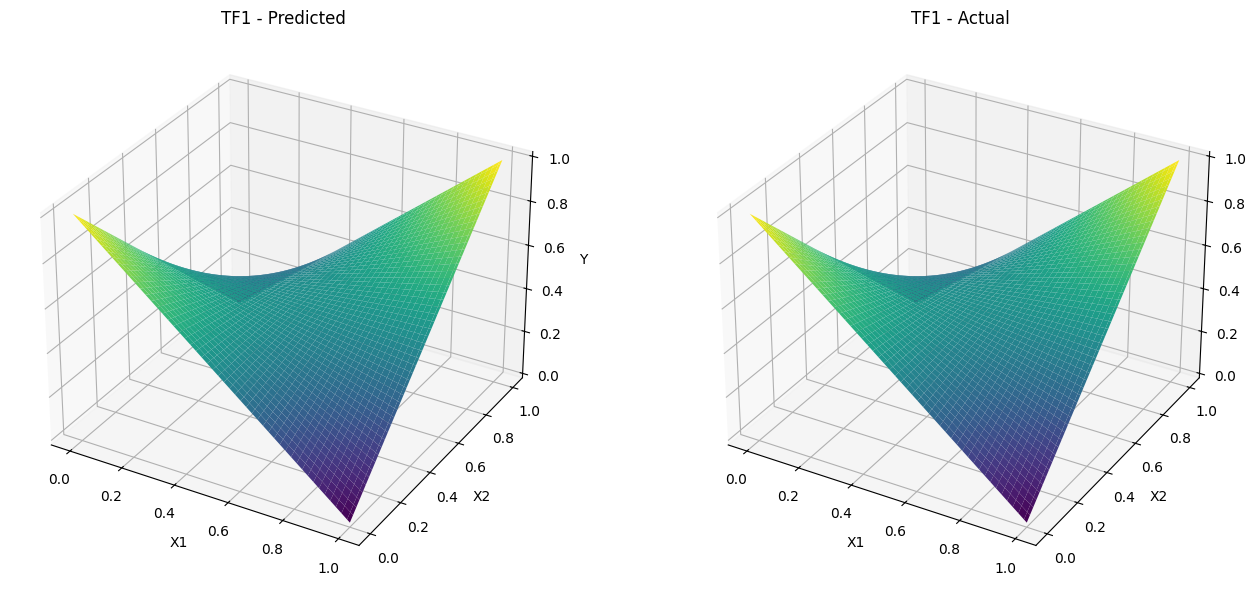

In [7]:
tf1_y_test_pred = utils.predict_hkan(tf1_model, tf1_x_test)
utils.plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_y_test_pred)

## KAN

In [8]:
tf1_kan_study = utils.study_optuna_kan("TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_trials = 10)

Results found for TF1. Loading from data/tf1_kan_optuna_search.csv
Best CV Validation RMSE: 0.161730
Best Test RMSE:          0.172035
Best width_idx:          2
Best architecture:       [2, 3, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.161730                 2  0.161730   0.172035
1       1  0.568877                 8  0.568877   0.274214
2       2  0.168665                 4  0.168665   0.298363
3       3  3.752602                 9  3.752602   0.568879
4       4  0.174820                 1  0.174820   0.179805
5       5  0.245464                 6  0.245464   0.178054
6       6  0.198778                 7  0.198778   0.172921
7       7  0.198986                 3  0.198986   0.190309
8       8  0.166398                 0  0.166398   0.170176
9       9  0.573112                 5  0.573112   1.370827


In [9]:
# Create TF1 KAN model with best architecture
tf1_kan_model = utils.build_kan(width=tf1_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [10]:
# Train and test TF1 KAN model
utils.fit_kan(tf1_kan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, steps=100, opt="Adam", lamb=1e-3)

tf1_kan_results = em.evaluate(
    utils.KANModel(tf1_kan_model),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

| train_loss: 1.67e-01 | test_loss: 1.71e-01 | reg: 2.88e+01 | : 100%|█| 100/100 [00:25<00:00,  3.90

saving model version 0.1

✓ KAN training completed in 25.6833 seconds


In [11]:
em.print_results(tf1_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.261283e-01         1.289797e-01        
RMSE            1.681006e-01         1.720347e-01        


In [12]:
tf1_y_test_pred_kan = utils.predict_kan(tf1_kan_model, tf1_x_test)

✓ KAN prediction completed in 0.0152 seconds


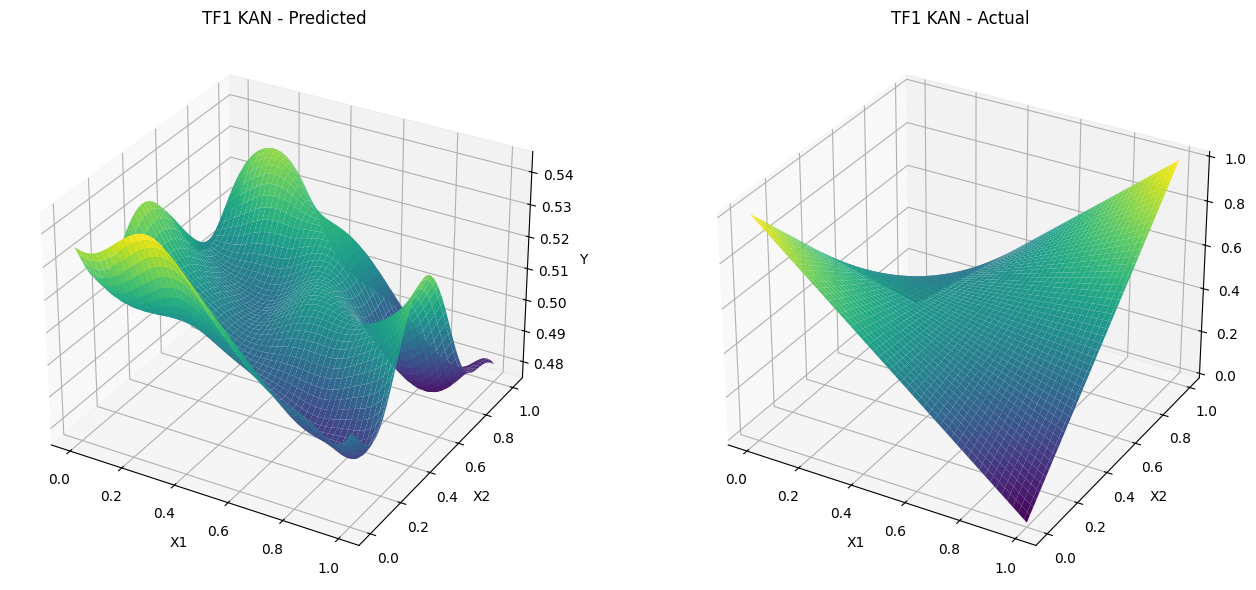

In [13]:
utils.plot_3d_surface("TF1 KAN", tf1_x_test, tf1_y_test, tf1_y_test_pred_kan)

## GP

In [14]:
kernel_types = ["rbf", "matern", "rq"]
tf1_gp_study = utils.study_optuna_gp("TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, n_trials = 10, kernel_types=kernel_types)

Results found for TF1. Loading from data/tf1_gp_optuna_search.csv
Best CV Validation RMSE: 0.019948
Best Test RMSE:          0.023966
Best lr:                 0.019415
Best kernel:             matern
Best num_inducing:       333

All 12 trials:
    number     value  params_lr params_kernel  params_num_inducing  val_rmse  test_rmse
0        0  0.110453   0.000538           rbf                  416  0.110453   0.135136
1        1  0.020348   0.015496        matern                  311  0.020348   0.023110
2        2  0.051657   0.000767            rq                  334  0.051657   0.062964
3        3  0.133662   0.000374           rbf                  421  0.133662   0.161665
4        4  0.055767   0.001536           rbf                  423  0.055767   0.047472
5        5  0.023018   0.004344            rq                  363  0.023018   0.026132
6        6  0.109728   0.000470           rbf                  479  0.109728   0.131682
7        7  0.028892   0.001989            rq      

In [18]:
tf1_gp_study

{'lr': 0.0194151152883173, 'kernel': 'matern', 'num_inducing': 333}

In [16]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf1_gp_study["kernel"], tf1_x_train)
tf1_gp_model, tf1_gp_likelihood = utils.init_and_fit_gp(
    tf1_x_train, tf1_y_train, kernel=kernel,
    num_inducing=tf1_gp_study["num_inducing"], lr=tf1_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf1_gp = utils.GPModel(tf1_gp_model, tf1_gp_likelihood)
tf1_gp_results = em.evaluate(
    tf1_gp,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)

em.print_results(tf1_gp_results)

# Make predictions for visualization
tf1_gp_y_test_pred = tf1_gp.predict(tf1_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=333

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0194151152883173, loss=ELBO
  Iter 100/500, Loss: 0.745907
  Iter 200/500, Loss: 0.742120
  Iter 300/500, Loss: 0.740923
  Iter 400/500, Loss: 0.740487
  Iter 500/500, Loss: 0.740251
[DEBUG] Training complete.
  Lengthscale: tensor([[1.1852, 0.9842]])
  Kernel type: MaternKernel
  Outputscale: 0.4083
  Noise: 0.693247
  Mean const: 0.3282
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             8.545357e-03         8.925824e-03        
RMSE            1.454207e-02         1.539430e-02        
[DEBUG] SparseG

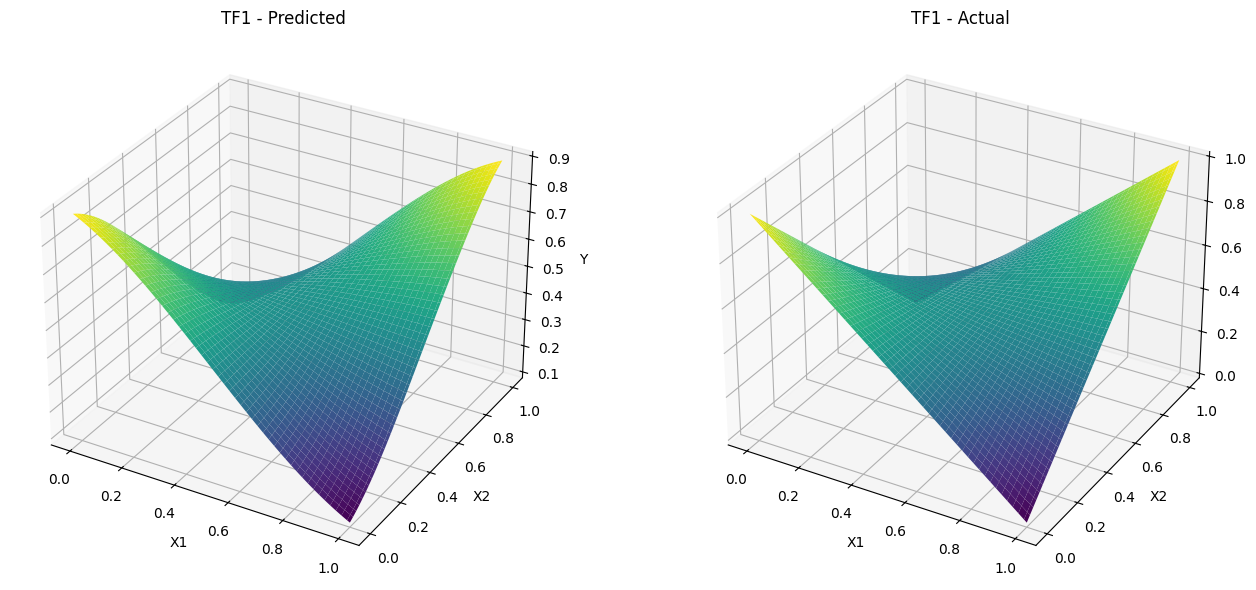

In [17]:
utils.plot_3d_surface("TF1", tf1_x_test, tf1_y_test, tf1_gp_y_test_pred)

# TF2 Experiments

## HKAN

In [19]:
# Load TF2 dataset
tf2 = load_dataset("TF2")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = tf2["train_input"], tf2["test_input"], tf2["train_label"], tf2["test_label"]

In [20]:
print("TF2 train describe")
display(pd.DataFrame(tf2_x_train).describe())
print("TF2 test describe")
display(pd.DataFrame(tf2_x_test).describe())
print("TF2 y_train describe")
display(pd.Series(tf2_y_train).describe())
print("TF2 y_test describe")
display(pd.Series(tf2_y_test).describe())

TF2 train describe


,0,1
count,5000.000000,5000.000000
mean,0.502861,0.502000
std,0.285424,0.285515
min,0.000133,0.000387
25%,0.259877,0.257710
50%,0.504340,0.502470
75%,0.747827,0.747088
max,0.999850,0.999980


TF2 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250002,0.250002
50%,0.500000,0.500000
75%,0.749997,0.749997
max,1.000000,1.000000


TF2 y_train describe


count    5000.000000
mean        0.482074
std         0.173621
min        -0.103030
25%         0.356747
50%         0.477600
75%         0.603375
max         1.145400
dtype: float64

TF2 y_test describe


count    10000.000000
mean         0.481887
std          0.129811
min          0.000000
25%          0.405035
50%          0.478680
75%          0.555480
max          1.000000
dtype: float64

In [21]:
# TF2 HKAN model params
tf2_model_params = [
    {
        "layer": 0,
        "n_vars_out": 48,
        "basis_fn": Tanh(s=22),
        "n_basis": 17,
        "centers": "random",
        "regressor": Ridge(alpha=0.1),
    },
    {
        "layer": 1,
        "n_vars_out": 11,
        "basis_fn": Softplus(s=18),
        "n_basis": 21,
        "centers": "random_data_points",
        "regressor": Ridge(alpha=1),
    },
    {
        "layer": 2,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        # Default configuration
        "n_basis": 10,
        "centers": "random",
        "regressor": Ridge(),
    }
]
tf2_model = utils.build_hkan_from_params(tf2_model_params)
tf2_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,48
,n_basis,17
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x31e022d90>
,base_regressor,Ridge(alpha=0.1)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [22]:
# Fit HKAN for TF2
utils.fit_hkan(tf2_model, tf2_x_train, tf2_y_train)
tf2_results = em.evaluate(
    tf2_model,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 351.78it/s]



✓ HKAN training completed in 2.3488 seconds


In [23]:
em.print_results(tf2_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.008521e-01         1.348625e-02        
RMSE            1.163214e-01         1.698008e-02        


✓ HKAN prediction completed in 2.0326 seconds


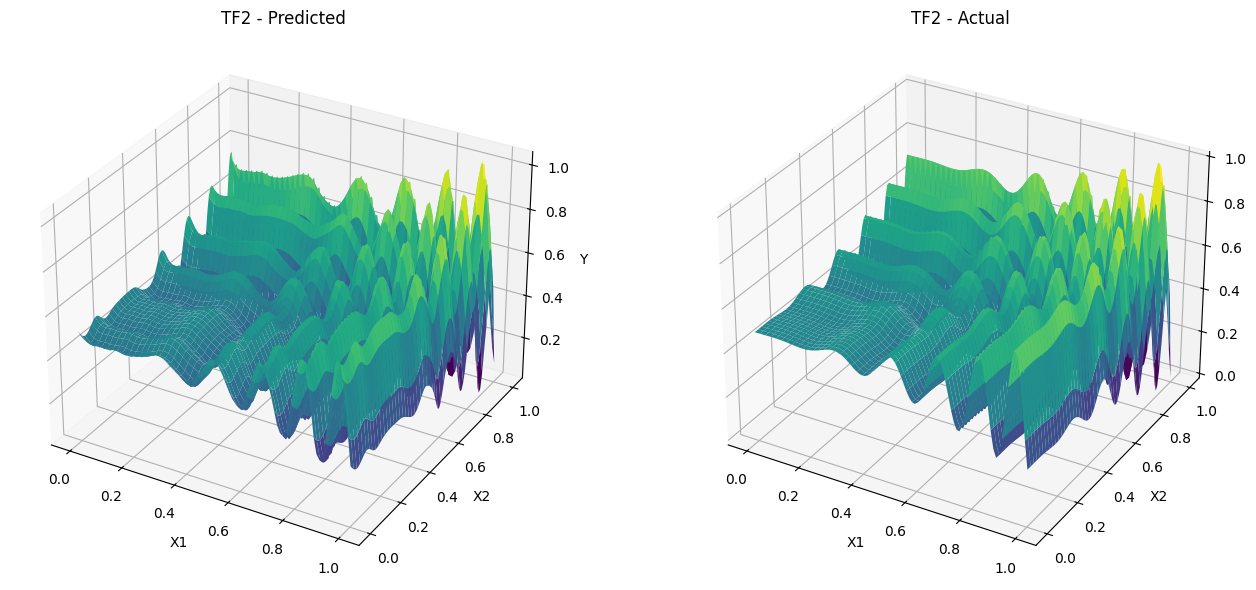

In [24]:
tf2_y_test_pred = utils.predict_hkan(tf2_model, tf2_x_test)
utils.plot_3d_surface("TF2", tf2_x_test, tf2_y_test, tf2_y_test_pred)

## KAN

In [25]:
tf2_kan_study = utils.study_optuna_kan("TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_trials=10)

Results found for TF2. Loading from data/tf2_kan_optuna_search.csv
Best CV Validation RMSE: 0.173447
Best Test RMSE:          0.129826
Best width_idx:          0
Best architecture:       [2, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.220154                 2  0.220154   0.134638
1       1  0.255157                 8  0.255157  10.841902
2       2  0.214038                 4  0.214038   0.239839
3       3  2.014279                 9  2.014279   0.431603
4       4  0.242890                 1  0.242890   0.132069
5       5  0.198356                 6  0.198356   0.130486
6       6  0.313805                 7  0.313805   0.488357
7       7  0.197938                 3  0.197938   0.181680
8       8  0.173447                 0  0.173447   0.129826
9       9  4.529024                 5  4.529024   0.473081


In [26]:
tf2_kan_model = utils.build_kan(width=tf2_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [27]:
utils.fit_kan(tf2_kan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, steps=100, opt="Adam", lamb=1e-3)

tf2_kan_results = em.evaluate(
    utils.KANModel(tf2_kan_model),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

| train_loss: 1.74e-01 | test_loss: 1.30e-01 | reg: 3.84e-01 | : 100%|█| 100/100 [00:23<00:00,  4.25

saving model version 0.1

✓ KAN training completed in 23.5582 seconds


In [28]:
em.print_results(tf2_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.403017e-01         9.761542e-02        
RMSE            1.734280e-01         1.298259e-01        


✓ KAN prediction completed in 0.0087 seconds


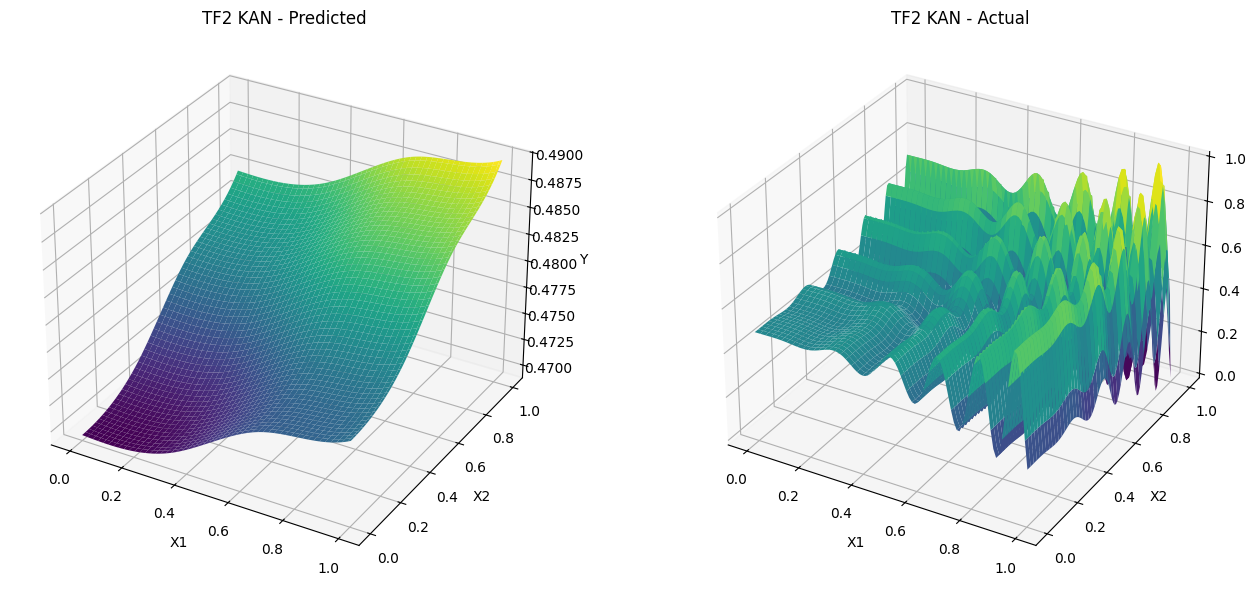

In [29]:
tf2_y_test_pred_kan = utils.predict_kan(tf2_kan_model, tf2_x_test)
utils.plot_3d_surface("TF2 KAN", tf2_x_test, tf2_y_test, tf2_y_test_pred_kan)

## GP

In [43]:
kernel_types = ["periodic", "periodic_rbf"]
tf2_gp_study = utils.study_optuna_gp("TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, n_trials = 10, kernel_types=kernel_types)

[I 2026-06-20 16:14:56,296] A new study created in memory with name: no-name-d8c79a74-2829-4879-8529-a64c22b1d803


Optimizing GP hyperparameters with 5-Fold CV on TF2


  0%|          | 0/10 [00:00<?, ?it/s]

[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=382

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.025713655493252583, loss=ELBO


/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py:464: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float64)
/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py:465: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float64)


  Iter 100/500, Loss: 0.770402
  Iter 200/500, Loss: 0.767871
  Iter 300/500, Loss: 0.766545
  Iter 400/500, Loss: 0.765516
  Iter 500/500, Loss: 0.764617
[DEBUG] Training complete.
  Lengthscale: tensor([[2.4601, 2.5797]])
  Kernel type: PeriodicKernel
  Outputscale: 0.2264
  Noise: 0.693247
  Mean const: 0.2952
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=382

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.025713655493252583, loss=ELBO
  Iter 100/500, Loss: 0.762428
  Iter 200/500, Loss: 0.761352
  Iter 300/500, Loss: 0.760746
  Iter 400/500, Loss: 0.760262
  Iter 500/500, Loss: 0.759858
[DEBUG] Training complete.
  Lengthscale: tensor([[5.7528, 6.0740]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0459
  Noise: 0.693247
  Mean const: 0.3912
[DEBUG] SparseGP

Best trial: 0. Best value: 0.173106:  10%|█         | 1/10 [05:03<45:29, 303.27s/it]

  Iter 500/500, Loss: 0.757504
[DEBUG] Training complete.
  Lengthscale: tensor([[9.7531, 8.5797]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0000
  Noise: 0.693247
  Mean const: 0.4820
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:19:59,562] Trial 0 finished with value: 0.17310641132627744 and parameters: {'lr': 0.025713655493252583, 'kernel': 'periodic', 'num_inducing': 382}. Best is trial 0 with value: 0.17310641132627744.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=485

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00010925589600314642, loss=ELBO
  Iter 100/500, Loss: 1.325130
  Iter 200/500, Loss: 1.220865
  Iter 300/500, Loss: 1.135189
  Iter 400/500, Loss: 1.070122
  Iter 500/500, Loss: 1.021178
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel ty

Best trial: 0. Best value: 0.173106:  20%|██        | 2/10 [13:26<56:09, 421.16s/it]

  Iter 500/500, Loss: 1.005261
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.5756
  Noise: 0.693247
  Mean const: 0.0488
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:28:23,242] Trial 1 finished with value: 0.33225812268814886 and parameters: {'lr': 0.00010925589600314642, 'kernel': 'periodic_rbf', 'num_inducing': 485}. Best is trial 0 with value: 0.17310641132627744.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=469

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.010142859060400147, loss=ELBO
  Iter 100/500, Loss: 0.782711
  Iter 200/500, Loss: 0.772172
  Iter 300/500, Loss: 0.769515
  Iter 400/500, Loss: 0.768256
  Iter 500/500, Loss: 0.767410
[DEBUG] Training complete.
  Lengthscale: tensor([[1.7874, 1.9546]])
  Kernel

Best trial: 2. Best value: 0.172201:  30%|███       | 3/10 [20:16<48:31, 415.98s/it]

  Iter 500/500, Loss: 0.758232
[DEBUG] Training complete.
  Lengthscale: tensor([[8.4608, 8.5564]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0043
  Noise: 0.693247
  Mean const: 0.4434
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:35:13,069] Trial 2 finished with value: 0.1722012662918737 and parameters: {'lr': 0.010142859060400147, 'kernel': 'periodic', 'num_inducing': 469}. Best is trial 2 with value: 0.1722012662918737.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=383

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0034356560693311732, loss=ELBO
  Iter 100/500, Loss: 0.836125
  Iter 200/500, Loss: 0.797126
  Iter 300/500, Loss: 0.783351
  Iter 400/500, Loss: 0.776465
  Iter 500/500, Loss: 0.772729
[DEBUG] Training complete.
  Lengthscale: tensor([[1.3751, 1.4907]])
  Kernel type: Pe

Best trial: 3. Best value: 0.171545:  40%|████      | 4/10 [25:45<38:09, 381.61s/it]

  Iter 500/500, Loss: 0.761876
[DEBUG] Training complete.
  Lengthscale: tensor([[3.5102, 3.8111]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0724
  Noise: 0.693247
  Mean const: 0.3278
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:40:41,975] Trial 3 finished with value: 0.17154463363985548 and parameters: {'lr': 0.0034356560693311732, 'kernel': 'periodic', 'num_inducing': 383}. Best is trial 3 with value: 0.17154463363985548.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=432

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0034272891021517003, loss=ELBO
  Iter 100/500, Loss: 0.827879
  Iter 200/500, Loss: 0.797535
  Iter 300/500, Loss: 0.786600
  Iter 400/500, Loss: 0.781162
  Iter 500/500, Loss: 0.778020
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel ty

Best trial: 4. Best value: 0.171319:  50%|█████     | 5/10 [32:30<32:29, 389.85s/it]

  Iter 500/500, Loss: 0.761762
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.0735
  Noise: 0.693247
  Mean const: 0.3033
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:47:26,449] Trial 4 finished with value: 0.17131916103273714 and parameters: {'lr': 0.0034272891021517003, 'kernel': 'periodic_rbf', 'num_inducing': 432}. Best is trial 4 with value: 0.17131916103273714.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=420

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.04326257694507791, loss=ELBO
  Iter 100/500, Loss: 0.770375
  Iter 200/500, Loss: 0.765591
  Iter 300/500, Loss: 0.762202
  Iter 400/500, Loss: 0.760876
  Iter 500/500, Loss: 0.760253
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kerne

Best trial: 4. Best value: 0.171319:  60%|██████    | 6/10 [38:37<25:28, 382.08s/it]

  Iter 500/500, Loss: 0.757494
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.0000
  Noise: 0.693247
  Mean const: 0.4821
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:53:33,444] Trial 5 finished with value: 0.1734202989876844 and parameters: {'lr': 0.04326257694507791, 'kernel': 'periodic_rbf', 'num_inducing': 420}. Best is trial 4 with value: 0.17131916103273714.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=330

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.04190813274695708, loss=ELBO
  Iter 100/500, Loss: 0.767482
  Iter 200/500, Loss: 0.765731
  Iter 300/500, Loss: 0.764539
  Iter 400/500, Loss: 0.763527
  Iter 500/500, Loss: 0.762682
[DEBUG] Training complete.
  Lengthscale: tensor([[3.1460, 3.3665]])
  Kernel type

Best trial: 4. Best value: 0.171319:  70%|███████   | 7/10 [43:03<17:12, 344.24s/it]

  Iter 500/500, Loss: 0.757493
[DEBUG] Training complete.
  Lengthscale: tensor([[6.4506, 7.0421]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0000
  Noise: 0.693247
  Mean const: 0.4821
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 16:57:59,768] Trial 6 finished with value: 0.17342336053774682 and parameters: {'lr': 0.04190813274695708, 'kernel': 'periodic', 'num_inducing': 330}. Best is trial 4 with value: 0.17131916103273714.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=335

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.006274061702612911, loss=ELBO
  Iter 100/500, Loss: 0.798034
  Iter 200/500, Loss: 0.777955
  Iter 300/500, Loss: 0.772409
  Iter 400/500, Loss: 0.770262
  Iter 500/500, Loss: 0.769149
[DEBUG] Training complete.
  Lengthscale: tensor([[1.4883, 1.5216]])
  Kernel type: Pe

Best trial: 4. Best value: 0.171319:  80%|████████  | 8/10 [47:30<10:39, 319.55s/it]

  Iter 500/500, Loss: 0.759449
[DEBUG] Training complete.
  Lengthscale: tensor([[5.6968, 5.4832]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0249
  Noise: 0.693247
  Mean const: 0.3926
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 17:02:26,468] Trial 7 finished with value: 0.17142386730511827 and parameters: {'lr': 0.006274061702612911, 'kernel': 'periodic', 'num_inducing': 335}. Best is trial 4 with value: 0.17131916103273714.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=465

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.019465198565907962, loss=ELBO
  Iter 100/500, Loss: 0.772034
  Iter 200/500, Loss: 0.768398
  Iter 300/500, Loss: 0.767084
  Iter 400/500, Loss: 0.766126
  Iter 500/500, Loss: 0.765312
[DEBUG] Training complete.
  Lengthscale: tensor([[2.4775, 2.4800]])
  Kernel type: P

Best trial: 4. Best value: 0.171319:  90%|█████████ | 9/10 [54:07<05:43, 343.85s/it]

  Iter 500/500, Loss: 0.757548
[DEBUG] Training complete.
  Lengthscale: tensor([[10.8316,  9.5543]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0001
  Noise: 0.693247
  Mean const: 0.4807
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 17:09:03,746] Trial 8 finished with value: 0.17294334668833355 and parameters: {'lr': 0.019465198565907962, 'kernel': 'periodic', 'num_inducing': 465}. Best is trial 4 with value: 0.17131916103273714.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=448

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00371227764757238, loss=ELBO
  Iter 100/500, Loss: 0.826402
  Iter 200/500, Loss: 0.795689
  Iter 300/500, Loss: 0.785202
  Iter 400/500, Loss: 0.780413
  Iter 500/500, Loss: 0.777230
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel typ

Best trial: 4. Best value: 0.171319: 100%|██████████| 10/10 [1:00:59<00:00, 365.93s/it]

  Iter 500/500, Loss: 0.761352
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.0760
  Noise: 0.693247
  Mean const: 0.2959
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 17:15:55,644] Trial 9 finished with value: 0.17202036168267593 and parameters: {'lr': 0.00371227764757238, 'kernel': 'periodic_rbf', 'num_inducing': 448}. Best is trial 4 with value: 0.17131916103273714.

Best trial results:
Best CV Validation RMSE: 0.171319
Best Test RMSE:          0.130506
Best lr:                 0.003427
Best kernel:             periodic_rbf
Best num_inducing:       432

All 10 trials:
   number     value  params_lr params_kernel  params_num_inducing  user_attrs_val_rmse  user_attrs_test_rmse
0       0  0.173106   0.025714      periodic                  382             0.173106              0.129803
1       1  0.332258   0.000109  periodic_rbf         

In [44]:
tf2_gp_study

{'lr': 0.0034272891021517003, 'kernel': 'periodic_rbf', 'num_inducing': 432}

In [45]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf2_gp_study["kernel"], tf2_x_train)
tf2_gp_model, tf2_gp_likelihood = utils.init_and_fit_gp(
    tf2_x_train, tf2_y_train, kernel=kernel,
    num_inducing=tf2_gp_study["num_inducing"], lr=tf2_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf2_gp = utils.GPModel(tf2_gp_model, tf2_gp_likelihood)
tf2_gp_results = em.evaluate(
    tf2_gp,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)

em.print_results(tf2_gp_results)

# Make predictions for visualization
tf2_gp_y_test_pred = tf2_gp.predict(tf2_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=432

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0034272891021517003, loss=ELBO


  Iter 100/500, Loss: 0.828894
  Iter 200/500, Loss: 0.797693
  Iter 300/500, Loss: 0.786467
  Iter 400/500, Loss: 0.780187
  Iter 500/500, Loss: 0.777068
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.4853
  Noise: 0.693247
  Mean const: 0.2033
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             1.311727e-01         8.723604e-02        
RMSE            1.617620e-01         1.185983e-01        
[DEBUG] SparseGPModel and likelihood frozen (eval mode)


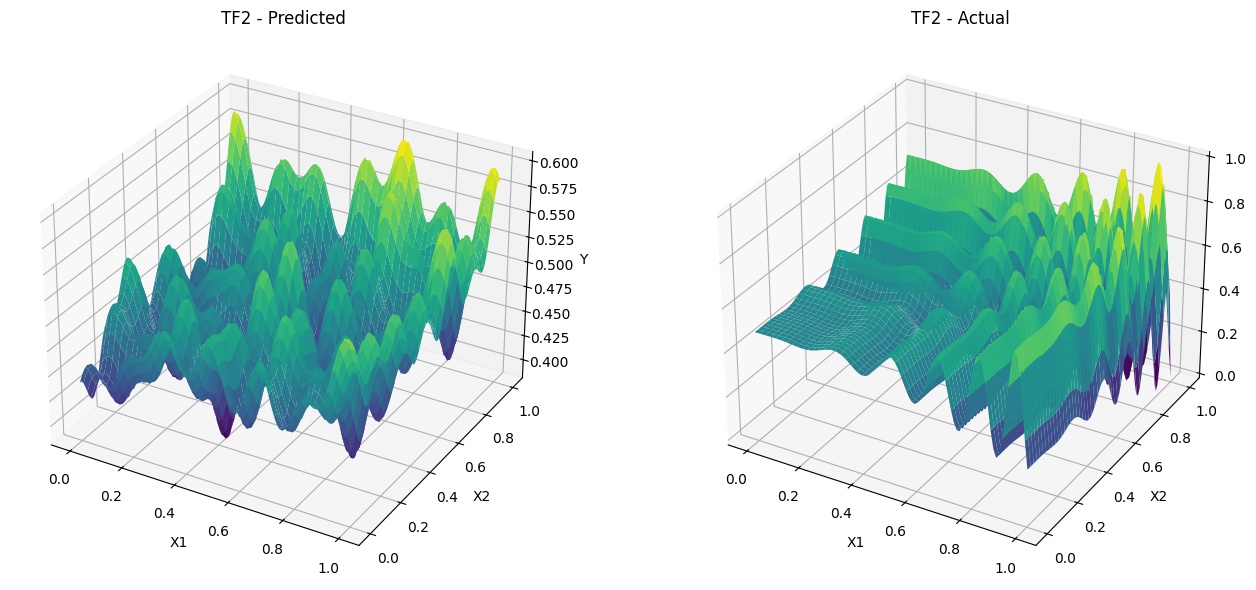

In [46]:
utils.plot_3d_surface("TF2", tf2_x_test, tf2_y_test, tf2_gp_y_test_pred)

# TF3 Experiments

## HKAN

In [47]:
# Load TF3 dataset
tf3 = load_dataset("TF3")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = tf3["train_input"], tf3["test_input"], tf3["train_label"], tf3["test_label"]

In [48]:
print("TF3 train describe")
display(pd.DataFrame(tf3_x_train).describe())
print("TF3 test describe")
display(pd.DataFrame(tf3_x_test).describe())
print("TF3 y_train describe")
display(pd.Series(tf3_y_train).describe())
print("TF3 y_test describe")
display(pd.Series(tf3_y_test).describe())

TF3 train describe


,0,1
count,5000.000000,5000.000000
mean,0.504802,0.500059
std,0.286061,0.284858
min,0.000433,0.000133
25%,0.261751,0.255484
50%,0.507392,0.498916
75%,0.749510,0.745363
max,0.999891,0.999982


TF3 test describe


,0,1
count,10000.000000,10000.000000
mean,0.500000,0.500000
std,0.291591,0.291591
min,0.000000,0.000000
25%,0.250000,0.250000
50%,0.500000,0.500000
75%,0.750000,0.750000
max,1.000000,1.000000


TF3 y_train describe


count    5000.000000
mean        0.502180
std         0.161040
min         0.005368
25%         0.392510
50%         0.501351
75%         0.612301
max         0.990860
dtype: float64

TF3 y_test describe


count    10000.000000
mean         0.500000
std          0.163565
min          0.000000
25%          0.388427
50%          0.500000
75%          0.611573
max          1.000000
dtype: float64

In [49]:
# TF3 HKAN model params
tf3_model_params = [
    {
        "layer": 0,
        "n_vars_out": 924,
        "basis_fn": Tanh(s=50),
        "n_basis": 39,
        "centers": "random",
        "regressor": Ridge(alpha=0.001),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf3_model = utils.build_hkan_from_params(tf3_model_params)
tf3_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,924
,n_basis,39
,centers,'random'
,basis_fn,<hkan.hkan.Ta...t 0x30ff0d990>
,base_regressor,Ridge(alpha=0.001)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [50]:
# Fit HKAN for TF3
utils.fit_hkan(tf3_model, tf3_x_train, tf3_y_train)
tf3_results = em.evaluate(
    tf3_model,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]



✓ HKAN training completed in 12.7987 seconds


In [51]:
em.print_results(tf3_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.754846e-06         3.888678e-06        
RMSE            9.324212e-06         6.590566e-06        


✓ HKAN prediction completed in 8.5117 seconds


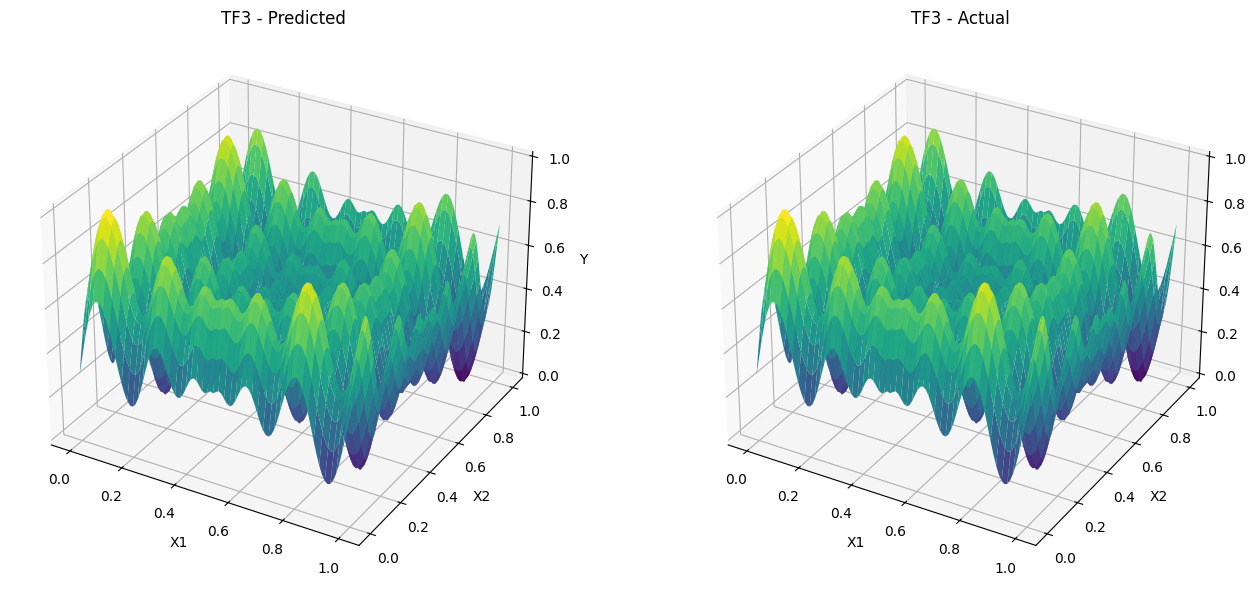

In [52]:
tf3_y_test_pred = utils.predict_hkan(tf3_model, tf3_x_test)
utils.plot_3d_surface("TF3", tf3_x_test, tf3_y_test, tf3_y_test_pred)

## KAN

In [53]:
tf3_kan_study = utils.study_optuna_kan("TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_trials=10)

Results found for TF3. Loading from data/tf3_kan_optuna_search.csv
Best CV Validation RMSE: 0.162384
Best Test RMSE:          0.164722
Best width_idx:          0
Best architecture:       [2, 1]

All 10 trials:
   number     value  params_width_idx  val_rmse  test_rmse
0       0  0.399037                 2  0.399037   0.160471
1       1  0.172992                 8  0.172992   0.164513
2       2  0.286203                 4  0.286203   0.163476
3       3  0.999206                 9  0.999206   0.163668
4       4  0.164660                 1  0.164660   0.487747
5       5  0.163563                 6  0.163563   0.163949
6       6  1.370679                 7  1.370679   0.361969
7       7  0.170057                 3  0.170057   0.182046
8       8  0.162384                 0  0.162384   0.164722
9       9  0.222863                 5  0.222863   0.196609


In [54]:
tf3_kan_model = utils.build_kan(width=tf3_kan_study["architecture"], grid=3, k=3, seed=42)

checkpoint directory created: ./model
saving model version 0.0


In [55]:
utils.fit_kan(tf3_kan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, steps=100, opt="Adam", lamb=1e-3)

tf3_kan_results = em.evaluate(
    utils.KANModel(tf3_kan_model),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

| train_loss: 1.61e-01 | test_loss: 1.64e-01 | reg: 2.67e-01 | : 100%|█| 100/100 [00:21<00:00,  4.60


saving model version 0.1

✓ KAN training completed in 21.7676 seconds


In [56]:
em.print_results(tf3_kan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.298408e-01         1.316747e-01        
RMSE            1.622684e-01         1.647225e-01        


✓ KAN prediction completed in 0.0054 seconds


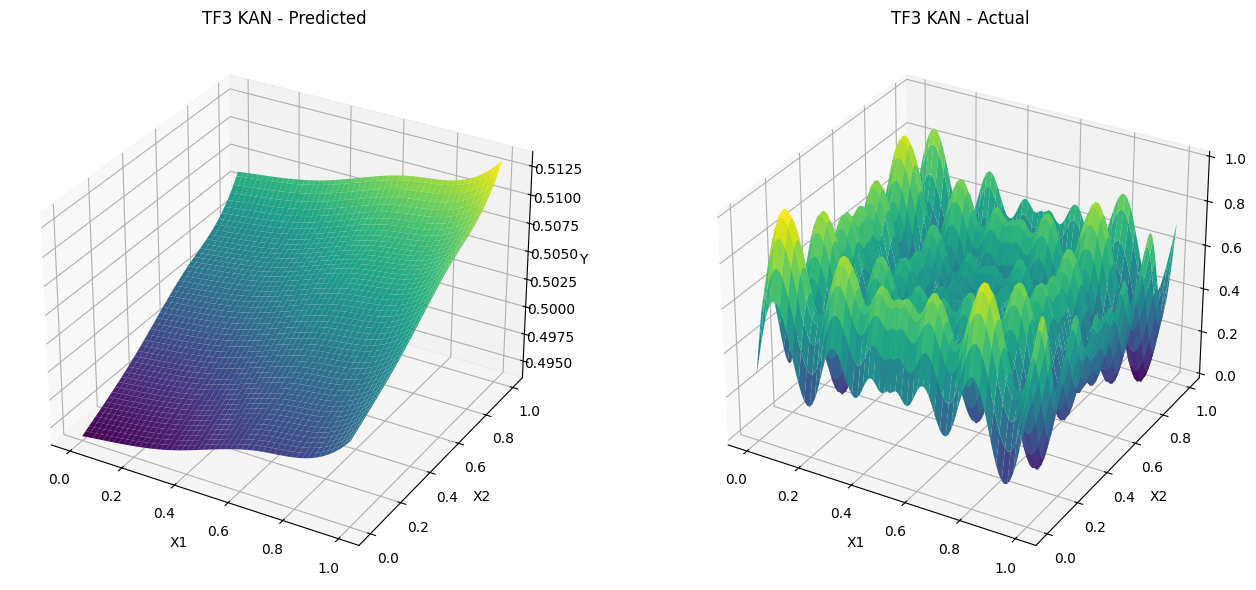

In [57]:
tf3_y_test_pred_kan = utils.predict_kan(tf3_kan_model, tf3_x_test)
utils.plot_3d_surface("TF3 KAN", tf3_x_test, tf3_y_test, tf3_y_test_pred_kan)

## GP

In [73]:
kernel_types = ["periodic", "periodic_rbf", "periodic_linear"]
tf3_gp_study = utils.study_optuna_gp("TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, n_trials = 10, kernel_types=kernel_types)

[I 2026-06-20 20:37:52,260] A new study created in memory with name: no-name-547e49d2-de56-4089-b778-f9738481aa53


Optimizing GP hyperparameters with 5-Fold CV on TF3


  0%|          | 0/10 [00:00<?, ?it/s]

[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=339

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.015428412472719158, loss=ELBO


/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py:464: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float64)
/Users/gizemnurdal/Workspace/swim-meets-kans/utils.py:465: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float64)


  Iter 100/500, Loss: 0.762688
  Iter 200/500, Loss: 0.756813
  Iter 300/500, Loss: 0.755344
  Iter 400/500, Loss: 0.754901
  Iter 500/500, Loss: 0.754642
[DEBUG] Training complete.
  Lengthscale: tensor([[1.5767, 1.5252]])
  Kernel type: PeriodicKernel
  Outputscale: 0.3623
  Noise: 0.693247
  Mean const: 0.2642
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=339

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.015428412472719158, loss=ELBO
  Iter 100/500, Loss: 0.758197
  Iter 200/500, Loss: 0.754950
  Iter 300/500, Loss: 0.753998
  Iter 400/500, Loss: 0.753831
  Iter 500/500, Loss: 0.753774
[DEBUG] Training complete.
  Lengthscale: tensor([[1.9302, 1.7481]])
  Kernel type: PeriodicKernel
  Outputscale: 0.1874
  Noise: 0.693247
  Mean const: 0.2923
[DEBUG] SparseGP

Best trial: 0. Best value: 0.098274:  10%|█         | 1/10 [04:12<37:50, 252.29s/it]

  Iter 500/500, Loss: 0.749196
[DEBUG] Training complete.
  Lengthscale: tensor([[0.1639, 9.9656]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0097
  Noise: 0.693247
  Mean const: 0.4939
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 20:42:04,553] Trial 0 finished with value: 0.09827397302848814 and parameters: {'lr': 0.015428412472719158, 'kernel': 'periodic', 'num_inducing': 339}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=491

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0008539220998860188, loss=ELBO
  Iter 100/500, Loss: 0.976888
  Iter 200/500, Loss: 0.873124
  Iter 300/500, Loss: 0.835623
  Iter 400/500, Loss: 0.816386
  Iter 500/500, Loss: 0.804488
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel typ

Best trial: 0. Best value: 0.098274:  20%|██        | 2/10 [11:32<48:23, 362.94s/it]

  Iter 500/500, Loss: 0.773416
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.2970
  Noise: 0.693247
  Mean const: 0.1702
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 20:49:24,947] Trial 1 finished with value: 0.1174037305594747 and parameters: {'lr': 0.0008539220998860188, 'kernel': 'periodic_rbf', 'num_inducing': 491}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=474

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0037270281938068146, loss=ELBO
  Iter 100/500, Loss: 0.793287
  Iter 200/500, Loss: 0.773143
  Iter 300/500, Loss: 0.765411
  Iter 400/500, Loss: 0.761591
  Iter 500/500, Loss: 0.759252
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kern

Best trial: 0. Best value: 0.098274:  30%|███       | 3/10 [18:32<45:22, 388.99s/it]

  Iter 500/500, Loss: 0.752022
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.1441
  Noise: 0.693247
  Mean const: 0.4812
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 20:56:24,945] Trial 2 finished with value: 0.11543058866356395 and parameters: {'lr': 0.0037270281938068146, 'kernel': 'periodic_linear', 'num_inducing': 474}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=361

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.04353257442445009, loss=ELBO
  Iter 100/500, Loss: 0.757250
  Iter 200/500, Loss: 0.755657
  Iter 300/500, Loss: 0.754807
  Iter 400/500, Loss: 0.754279
  Iter 500/500, Loss: 0.753890
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Ke

Best trial: 0. Best value: 0.098274:  40%|████      | 4/10 [23:40<35:41, 356.92s/it]

  Iter 500/500, Loss: 0.748952
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.0134
  Noise: 0.693247
  Mean const: 0.5017
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:01:32,686] Trial 3 finished with value: 0.11077661911828682 and parameters: {'lr': 0.04353257442445009, 'kernel': 'periodic_rbf', 'num_inducing': 361}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=390

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.03272506817550863, loss=ELBO
  Iter 100/500, Loss: 0.755952
  Iter 200/500, Loss: 0.754505
  Iter 300/500, Loss: 0.754271
  Iter 400/500, Loss: 0.754121
  Iter 500/500, Loss: 0.754005
[DEBUG] Training complete.
  Lengthscale: tensor([[1.7571, 1.7570]])
  Kernel typ

Best trial: 0. Best value: 0.098274:  50%|█████     | 5/10 [28:39<28:00, 336.10s/it]

  Iter 500/500, Loss: 0.749051
[DEBUG] Training complete.
  Lengthscale: tensor([[ 0.1705, 26.9778]])
  Kernel type: PeriodicKernel
  Outputscale: 0.0110
  Noise: 0.693247
  Mean const: 0.5015
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:06:31,880] Trial 4 finished with value: 0.10714023544094622 and parameters: {'lr': 0.03272506817550863, 'kernel': 'periodic', 'num_inducing': 390}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=420

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.0021682038591208114, loss=ELBO
  Iter 100/500, Loss: 0.822032
  Iter 200/500, Loss: 0.788247
  Iter 300/500, Loss: 0.776534
  Iter 400/500, Loss: 0.770269
  Iter 500/500, Loss: 0.765979
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel ty

Best trial: 0. Best value: 0.098274:  60%|██████    | 6/10 [34:43<23:01, 345.49s/it]

  Iter 500/500, Loss: 0.755980
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.2167
  Noise: 0.693247
  Mean const: 0.3934
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:12:35,601] Trial 5 finished with value: 0.12337886388844703 and parameters: {'lr': 0.0021682038591208114, 'kernel': 'periodic_linear', 'num_inducing': 420}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=468

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.007484913213658287, loss=ELBO
  Iter 100/500, Loss: 0.771078
  Iter 200/500, Loss: 0.760700
  Iter 300/500, Loss: 0.757990
  Iter 400/500, Loss: 0.756592
  Iter 500/500, Loss: 0.755861
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  K

Best trial: 0. Best value: 0.098274:  70%|███████   | 7/10 [41:33<18:20, 366.72s/it]

  Iter 500/500, Loss: 0.750052
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.1079
  Noise: 0.693247
  Mean const: 0.5450
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:19:26,020] Trial 6 finished with value: 0.11557760987701796 and parameters: {'lr': 0.007484913213658287, 'kernel': 'periodic_linear', 'num_inducing': 468}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=429

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.00016385274744559568, loss=ELBO
  Iter 100/500, Loss: 1.092114
  Iter 200/500, Loss: 1.016677
  Iter 300/500, Loss: 0.962220
  Iter 400/500, Loss: 0.924014
  Iter 500/500, Loss: 0.896116
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  

Best trial: 0. Best value: 0.098274:  80%|████████  | 8/10 [47:47<12:18, 369.10s/it]

  Iter 500/500, Loss: 0.885266
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.5446
  Noise: 0.693247
  Mean const: 0.0732
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:25:40,221] Trial 7 finished with value: 0.34791292014265396 and parameters: {'lr': 0.00016385274744559568, 'kernel': 'periodic_linear', 'num_inducing': 429}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=481

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.019802135200655543, loss=ELBO
  Iter 100/500, Loss: 0.762411
  Iter 200/500, Loss: 0.758433
  Iter 300/500, Loss: 0.756885
  Iter 400/500, Loss: 0.755948
  Iter 500/500, Loss: 0.755296
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  

Best trial: 0. Best value: 0.098274:  90%|█████████ | 9/10 [55:29<06:37, 397.87s/it]

  Iter 500/500, Loss: 0.749039
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.0118
  Noise: 0.693247
  Mean const: 0.5001
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:33:21,337] Trial 8 finished with value: 0.10410306524435364 and parameters: {'lr': 0.019802135200655543, 'kernel': 'periodic_rbf', 'num_inducing': 481}. Best is trial 0 with value: 0.09827397302848814.
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([4000, 2]), num_inducing=386

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.011153530045485102, loss=ELBO
  Iter 100/500, Loss: 0.771974
  Iter 200/500, Loss: 0.762292
  Iter 300/500, Loss: 0.759537
  Iter 400/500, Loss: 0.758125
  Iter 500/500, Loss: 0.757161
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kerne

Best trial: 9. Best value: 0.0957734: 100%|██████████| 10/10 [1:00:58<00:00, 365.90s/it]

  Iter 500/500, Loss: 0.749465
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.0149
  Noise: 0.693247
  Mean const: 0.4453
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[I 2026-06-20 21:38:51,238] Trial 9 finished with value: 0.09577337428229658 and parameters: {'lr': 0.011153530045485102, 'kernel': 'periodic_rbf', 'num_inducing': 386}. Best is trial 9 with value: 0.09577337428229658.

Best trial results:
Best CV Validation RMSE: 0.095773
Best Test RMSE:          0.113155
Best lr:                 0.011154
Best kernel:             periodic_rbf
Best num_inducing:       386

All 10 trials:
   number     value  params_lr    params_kernel  params_num_inducing  user_attrs_val_rmse  user_attrs_test_rmse
0       0  0.098274   0.015428         periodic                  339             0.098274              0.117043
1       1  0.117404   0.000854     periodic_rb

In [74]:
tf3_gp_study

{'lr': 0.011153530045485102, 'kernel': 'periodic_rbf', 'num_inducing': 386}

In [75]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf3_gp_study["kernel"], tf3_x_train)
tf3_gp_model, tf3_gp_likelihood = utils.init_and_fit_gp(
    tf3_x_train, tf3_y_train, kernel=kernel,
    num_inducing=tf3_gp_study["num_inducing"], lr=tf3_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf3_gp = utils.GPModel(tf3_gp_model, tf3_gp_likelihood)
tf3_gp_results = em.evaluate(
    tf3_gp,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)

em.print_results(tf3_gp_results)

# Make predictions for visualization
tf3_gp_y_test_pred = tf3_gp.predict(tf3_x_test)


Training GP...
[DEBUG] Initialized SparseGPModel: X_train.shape=torch.Size([5000, 2]), num_inducing=386

Training GP...
[DEBUG] SparseGPModel and likelihood unfrozen (train mode)
[DEBUG] Training SparseGPModel: 500 iters, lr=0.011153530045485102, loss=ELBO
  Iter 100/500, Loss: 0.768389
  Iter 200/500, Loss: 0.759133
  Iter 300/500, Loss: 0.756851
  Iter 400/500, Loss: 0.755680
  Iter 500/500, Loss: 0.754927
[DEBUG] Training complete.
  Lengthscale: Not available for this kernel
  Kernel type: ProductKernel
  Outputscale: 0.3783
  Noise: 0.693247
  Mean const: 0.2216
[DEBUG] SparseGPModel and likelihood frozen (eval mode)

Evaluating GP...
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
[DEBUG] SparseGPModel and likelihood frozen (eval mode)
Metric          Train                Test                
-------------------------------------------------------
MAE             5.525580e-02         5.791855e-02        
RMSE            6.801573e-02         7.146503e-02        
[DEBUG] S

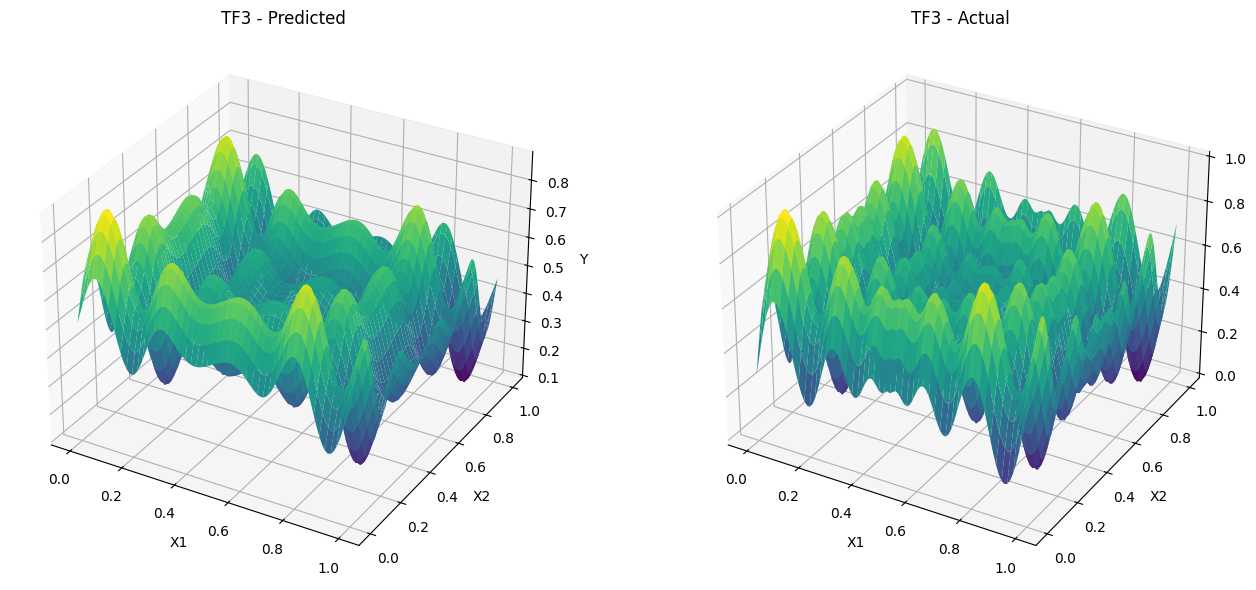

In [76]:
utils.plot_3d_surface("TF3", tf3_x_test, tf3_y_test, tf3_gp_y_test_pred)

# TF4 Experiments

## HKAN

In [ ]:
# Load TF4 dataset
tf4 = load_dataset("TF4")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = tf4["train_input"], tf4["test_input"], tf4["train_label"], tf4["test_label"]

In [ ]:
print("TF4 train describe")
display(pd.DataFrame(tf4_x_train).describe())
print("TF4 test describe")
display(pd.DataFrame(tf4_x_test).describe())
print("TF4 y_train describe")
display(pd.Series(tf4_y_train).describe())
print("TF4 y_test describe")
display(pd.Series(tf4_y_test).describe())

In [ ]:
# TF4 HKAN model params
tf4_model_params = [
    {
        "layer": 0,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=3),
        "n_basis": 2,
        "centers": "equally_spaced",
        "regressor": Ridge(alpha=0.001),
    }
]
tf4_model = utils.build_hkan_from_params(tf4_model_params)
tf4_model

In [ ]:
# Fit HKAN for TF4
utils.fit_hkan(tf4_model, tf4_x_train, tf4_y_train)
tf4_results = em.evaluate(
    tf4_model,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

In [ ]:
em.print_results(tf4_results)

In [ ]:
tf4_y_test_pred = utils.predict_hkan(tf4_model, tf4_x_test)
utils.plot_3d_surface("TF4", tf4_x_test, tf4_y_test, tf4_y_test_pred)

## KAN

In [ ]:
tf4_kan_study = utils.study_optuna_kan("TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials=10)

In [ ]:
tf4_kan_model = utils.build_kan(width=tf4_kan_study["architecture"], grid=3, k=3, seed=42)

In [ ]:
utils.fit_kan(tf4_kan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, steps=100, opt="Adam", lamb=1e-3)

tf4_kan_results = em.evaluate(
    utils.KANModel(tf4_kan_model),
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

In [ ]:
em.print_results(tf4_kan_results)

In [ ]:
tf4_y_test_pred_kan = utils.predict_kan(tf4_kan_model, tf4_x_test)
utils.plot_3d_surface("TF4 KAN", tf4_x_test, tf4_y_test, tf4_y_test_pred_kan)

## GP

In [ ]:
kernel_types = ["periodic", "rq"]
tf4_gp_study = utils.study_optuna_gp("TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials = 10, kernel_types=kernel_types)

In [ ]:
tf4_gp_study

In [ ]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf4_gp_study["kernel"], tf4_x_train)
tf4_gp_model, tf4_gp_likelihood = utils.init_and_fit_gp(
    tf4_x_train, tf4_y_train, kernel=kernel,
    num_inducing=tf4_gp_study["num_inducing"], lr=tf4_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf4_gp = utils.GPModel(tf4_gp_model, tf4_gp_likelihood)
tf4_gp_results = em.evaluate(
    tf4_gp,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)

em.print_results(tf4_gp_results)

# Make predictions for visualization
tf4_gp_y_test_pred = tf4_gp.predict(tf4_x_test)

In [ ]:
utils.plot_3d_surface("TF4", tf4_x_test, tf4_y_test, tf4_gp_y_test_pred)

# TF5 Experiments

## HKAN

In [ ]:
# Load TF5 dataset
tf5 = load_dataset("TF5")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = tf5["train_input"], tf5["test_input"], tf5["train_label"], tf5["test_label"]

In [ ]:
print("TF5 train describe")
display(pd.DataFrame(tf5_x_train).describe())
print("TF5 test describe")
display(pd.DataFrame(tf5_x_test).describe())
print("TF5 y_train describe")
display(pd.Series(tf5_y_train).describe())
print("TF5 y_test describe")
display(pd.Series(tf5_y_test).describe())

In [ ]:
# tf5 HKAN model params
tf5_model_params = [
    {
        "layer": 0,
        "n_vars_out": 912,
        "basis_fn": Tanh(s=50),
        "n_basis": 23,
        "centers": "random",
        "regressor": Ridge(alpha=0.01),
    },
    {
        "layer": 1,
        "n_vars_out": 1,
        "basis_fn": Identity(),
        "n_basis": 10,
        "centers": "random_data_points",
        "regressor": Ridge(),
    }
]
tf5_model = utils.build_hkan_from_params(tf5_model_params)
tf5_model

In [ ]:
# Fit HKAN for TF5
utils.fit_hkan(tf5_model, tf5_x_train, tf5_y_train)
tf5_results = em.evaluate(
    tf5_model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
em.print_results(tf5_results)

In [ ]:
tf5_y_test_pred = utils.predict_hkan(tf5_model, tf5_x_test)
utils.plot_3d_surface("TF5", tf5_x_test, tf5_y_test, tf5_y_test_pred)

## KAN

In [ ]:
tf5_kan_study = utils.study_optuna_kan("TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_trials=10)

In [ ]:
tf5_kan_model = utils.build_kan(width=tf5_kan_study["architecture"], grid=3, k=3, seed=42)

In [ ]:
utils.fit_kan(tf5_kan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, steps=100, opt="Adam", lamb=1e-3)

tf5_kan_results = em.evaluate(
    utils.KANModel(tf5_kan_model),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

In [ ]:
em.print_results(tf5_kan_results)

In [ ]:
tf5_y_test_pred_kan = utils.predict_kan(tf5_kan_model, tf5_x_test)
utils.plot_3d_surface("TF5 KAN", tf5_x_test, tf5_y_test, tf5_y_test_pred_kan)

## GP

In [ ]:
kernel_types = ["periodic_rbf", "periodic", "periodic_linear"]
tf5_gp_study = utils.study_optuna_gp("TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, n_trials = 10, kernel_types=kernel_types)

In [ ]:
tf5_gp_study

In [ ]:
print("\nTraining GP...")
kernel = utils.kernel_factory(tf5_gp_study["kernel"], tf5_x_train)
tf5_gp_model, tf5_gp_likelihood = utils.init_and_fit_gp(
    tf5_x_train, tf5_y_train, kernel=kernel,
    num_inducing=tf5_gp_study["num_inducing"], lr=tf5_gp_study["lr"])

# Evaluate GP model
print("\nEvaluating GP...")
tf5_gp = utils.GPModel(tf5_gp_model, tf5_gp_likelihood)
tf5_gp_results = em.evaluate(
    tf5_gp,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)

em.print_results(tf5_gp_results)

# Make predictions for visualization
tf5_gp_y_test_pred = tf5_gp.predict(tf5_x_test)

In [ ]:
utils.plot_3d_surface("TF5", tf5_x_test, tf5_y_test, tf5_gp_y_test_pred)